Dataset shape: (112120, 12)
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_001.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           57              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           80              M            PA                 2500     2048   
4           74              F            PA                 2500     2048   

   OriginalImagePixelSpacing[x     y]  \
0                        0.143  0.1

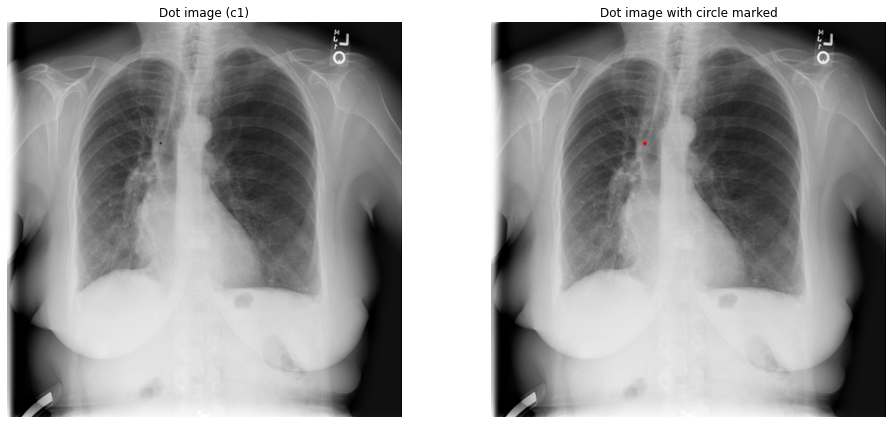

Saved: /home/jupyter-yin10/Image_Analysis/ResNet50/c1/train_manifest.csv rows: 89696
Saved: /home/jupyter-yin10/Image_Analysis/ResNet50/c1/test_manifest.csv rows: 22424


In [1]:
import os, shutil, random, hashlib
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from PIL import Image, ImageDraw

# ----------------------
# Paths
# ----------------------
WORK_DIR = Path("/home/jupyter-yin10/Image_Analysis")
IMG_DIR  = Path("/data0/NIH-CXR14/images")
RAW_CSV  = Path("/data0/NIH-CXR14/Data_Entry_2017_v2020.csv")

# Output root for ResNet50 experiment
out_root = WORK_DIR / "ResNet50" / "c1"

# Optional metadata copies (same as before)
SAMPLE_CSV        = WORK_DIR / "meta_NIH-CXR14.csv"
SAMPLE_WITH_PATHS = WORK_DIR / "meta_NIH-CXR14_with_paths.csv"

WORK_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------
# Settings
# ----------------------
SEED = 42
TARGET_SIZE = 448
circle_radius = 1

# ----------------------
# Load metadata
# ----------------------
df_meta = pd.read_csv(RAW_CSV)
df_meta.to_csv(SAMPLE_CSV, index=False)

df = df_meta.copy()
df["Image Path"] = str(IMG_DIR) + "/" + df["Image Index"].astype(str)
df.to_csv(SAMPLE_WITH_PATHS, index=False)

print("Dataset shape:", df.shape)
print(df.head())

# ----------------------
# Helpers, deterministic per-image "randomness"
# ----------------------
def _seed_from_name(name: str, base_seed: int) -> int:
    h = hashlib.sha256()
    h.update(str(base_seed).encode("utf-8"))
    h.update(b"::")
    h.update(name.encode("utf-8"))
    return int.from_bytes(h.digest()[:8], "little", signed=False)

def _open_resized_L(img_path: Path, target: int = TARGET_SIZE) -> Image.Image:
    img = Image.open(img_path).convert("L")
    if img.size != (target, target):
        img = img.resize((target, target), resample=Image.Resampling.LANCZOS)
    return img

def choose_random_center(img_path: Path, radius: int, base_seed: int, key_str: str) -> tuple[int, int]:
    # resize first, then choose center using resized dims
    with _open_resized_L(img_path) as im:
        w, h = im.size

    xmin, xmax = radius, max(radius, w - 1 - radius)
    ymin, ymax = radius, max(radius, h - 1 - radius)
    if xmax < xmin or ymax < ymin:
        return (w // 2, h // 2)

    s = _seed_from_name(key_str, base_seed)
    rng = random.Random(s)
    return (rng.randint(xmin, xmax), rng.randint(ymin, ymax))

def compute_intensity(img_path: Path, base_seed: int, key_str: str) -> int:
    # resize first, then histogram mode, then sample mode ± 20
    with _open_resized_L(img_path) as img:
        hist = img.histogram()[:256]

    x = int(np.argmax(hist))
    lo = max(0, x - 20)
    hi = min(255, x + 20)

    rs = _seed_from_name("intensity::" + key_str, base_seed)
    rng = random.Random(rs)
    return int(rng.randint(lo, hi))

def save_nodot_resized(src: Path, dst: Path):
    img = _open_resized_L(src)
    dst.parent.mkdir(parents=True, exist_ok=True)
    img.save(dst)
    img.close()

def add_circle(src: Path, dst: Path, center: tuple[int, int], radius: int, intensity: int):
    img = _open_resized_L(src)
    draw = ImageDraw.Draw(img)
    cx, cy = center
    r = int(radius)
    if r > 0:
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=int(intensity))
    dst.parent.mkdir(parents=True, exist_ok=True)
    img.save(dst)
    img.close()

def label_balanced(dframe: pd.DataFrame, seed: int):
    n = len(dframe)
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    half = n // 2
    with_dot = set(idx[:half])
    dframe["label"] = ["dot" if i in with_dot else "nodot" for i in range(n)]
    return dframe

def _process_row(r, split: str):
    src = Path(r["Image Path"])
    dst = out_root / split / r["label"] / Path(r["Image Index"]).name

    if r["label"] == "dot":
        base_seed = SEED if split == "train" else SEED + 1

        center = choose_random_center(
            img_path=src,
            radius=circle_radius,
            base_seed=base_seed,
            key_str=str(dst.name)
        )

        intensity = compute_intensity(
            img_path=src,
            base_seed=base_seed,
            key_str=str(dst.name)
        )

        add_circle(src, dst, center=center, radius=circle_radius, intensity=intensity)
    else:
        # nodot is also resized and saved (no linking), so dimensions match dot images
        save_nodot_resized(src, dst)

def materialize_split_parallel(dframe: pd.DataFrame, split: str, workers: int = 8, log_every: int = 2000):
    total = len(dframe)
    with ThreadPoolExecutor(max_workers=workers) as ex:
        futs = [ex.submit(_process_row, r, split) for _, r in dframe.iterrows()]
        for i, f in enumerate(as_completed(futs), 1):
            _ = f.result()
            if i % log_every == 0 or i == total:
                print(f"[{split}] {i}/{total} ({i/total:.1%})")

# ----------------------
# Shuffle, split 80/20, then balance labels in each split
# ----------------------
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
n_total = len(df)
n_train = int(n_total * 0.8)

train_df = df.iloc[:n_train].copy()
test_df  = df.iloc[n_train:].copy()

train_df = label_balanced(train_df, SEED)
test_df  = label_balanced(test_df, SEED)

print("Train label counts:\n", train_df["label"].value_counts())
print("Test label counts:\n", test_df["label"].value_counts())

# ----------------------
# Write images
# ----------------------
shutil.rmtree(out_root, ignore_errors=True)
out_root.mkdir(parents=True, exist_ok=True)

materialize_split_parallel(train_df, "train")
materialize_split_parallel(test_df, "test")

print("Done writing images to:", out_root)

# ----------------------
# Basic verification
# ----------------------
def count_pngs(folder: Path):
    return sum(1 for _ in folder.glob("*.png"))

train_dot   = out_root / "train" / "dot"
train_nodot = out_root / "train" / "nodot"
test_dot    = out_root / "test" / "dot"
test_nodot  = out_root / "test" / "nodot"

print("Counts:")
print("Train/dot:", count_pngs(train_dot))
print("Train/nodot:", count_pngs(train_nodot))
print("Test/dot:", count_pngs(test_dot))
print("Test/nodot:", count_pngs(test_nodot))

for folder in [train_dot, train_nodot, test_dot, test_nodot]:
    files = list(folder.glob("*.png"))
    if files:
        with Image.open(files[0]) as im:
            print(folder, "first image size:", im.size)

# Check one dot image for correct injected intensity at the deterministic center
dot_images = list(train_dot.glob("*.png"))
img_path = dot_images[0]
x, y = choose_random_center(img_path=img_path, radius=circle_radius, base_seed=SEED, key_str=str(img_path.name))
used_intensity = compute_intensity(img_path=img_path, base_seed=SEED, key_str=str(img_path.name))

img = Image.open(img_path).convert("L")
arr = np.array(img)
h, w = arr.shape
yy, xx = np.ogrid[:h, :w]
mask = (xx - x) ** 2 + (yy - y) ** 2 <= circle_radius ** 2

print("Unique values inside circle:", np.unique(arr[mask]))
print("Expected intensity:", used_intensity)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(arr, cmap="gray")
ax1.set_title("Dot image (c1)")

ax2.imshow(arr, cmap="gray")
ax2.add_patch(Circle((x, y), circle_radius, fill=False, edgecolor="red", linewidth=2))
ax2.set_title("Dot image with circle marked")
for ax in (ax1, ax2):
    ax.axis("off")
plt.tight_layout()
plt.show()

# ----------------------
# Manifests (same format as before)
# ----------------------
LABEL_MAP = {"dot": 1, "nodot": 0}

def make_manifest(split: str, root: Path = out_root, label_map: dict = LABEL_MAP, pattern: str = "*.png") -> pd.DataFrame:
    rows = []
    for label_name, label_id in label_map.items():
        folder = root / split / label_name
        for p in sorted(folder.glob(pattern)):
            rows.append({"path": str(p), "label": int(label_id)})
    return pd.DataFrame(rows, columns=["path", "label"])

train_manifest = make_manifest("train")
test_manifest  = make_manifest("test")

train_manifest_path = out_root / "train_manifest.csv"
test_manifest_path  = out_root / "test_manifest.csv"

train_manifest.to_csv(train_manifest_path, index=False)
test_manifest.to_csv(test_manifest_path, index=False)

print("Saved:", train_manifest_path, "rows:", len(train_manifest))
print("Saved:", test_manifest_path, "rows:", len(test_manifest))


Device: cuda
GPU: NVIDIA GeForce RTX 3090
Rows: train 80726 val 8970 test 22424
Train label counts:
 label
1    40363
0    40363
Name: count, dtype: int64
Val   label counts:
 label
1    4485
0    4485
Name: count, dtype: int64
Test  label counts:
 label
1    11212
0    11212
Name: count, dtype: int64
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jupyter-yin10/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s] 


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train 1/10:   0%|          | 0/2523 [00:00<?, ?it/s]

Val loss 1/10:   0%|          | 0/281 [00:00<?, ?it/s]

...

<function _MultiProcessingDataLoaderIter.__del__ at 0x7f7f7803ad30><function _MultiProcessingDataLoaderIter.__del__ at 0x7f7f7803ad30>
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f7f7803ad30>
Traceback (most recent call last):

Traceback (most recent call last):
  File "/home/jupyter-yin10/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
Traceback (most recent call last):
  File "/home/jupyter-yin10/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
  File "/home/jupyter-yin10/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
        self._shutdown_workers()    self._shutdown_workers()
self._shutdown_workers()
  File "/home/jupyter-yin10/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers

  File "/home/jupyter-yin10/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_wo

    assert self._parent_pid == os.getpid(), 'can only test a child process'<function _MultiProcessingDataLoaderIter.__del__ at 0x7f7f7803ad30>
    assert self._parent_pid == os.getpid(), 'can only test a child process'
if w.is_alive():Traceback (most recent call last):
AssertionError

: AssertionError  File "/home/jupyter-yin10/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1664, in __del__
  File "/opt/tljh/user/lib/python3.9/multiprocessing/process.py", line 160, in is_alive
can only test a child process:         
can only test a child processself._shutdown_workers()assert self._parent_pid == os.getpid(), 'can only test a child process'


Exception ignored in: AssertionError  File "/home/jupyter-yin10/.local/lib/python3.9/site-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f7f7803ad30>:     
can only test a child processif w.is_alive():Traceback (most recent call last):


  Fil

Best val AUC: 0.9840980153092993
Saved best checkpoint: /home/jupyter-yin10/Image_Analysis/ResNet50/c1/runs/resnet50_imagenet_v2/best.pt


Test probs:   0%|          | 0/701 [00:00<?, ?it/s]


Test results
Accuracy: 0.974937566892615
Precision: 0.9958100558659218
Recall: 0.953888690688548
F1: 0.9743986880466472
ROC AUC: 0.9860829154686082

Confusion matrix:
 [[11167    45]
 [  517 10695]]

Classification report:
               precision    recall  f1-score   support

           0     0.9558    0.9960    0.9755     11212
           1     0.9958    0.9539    0.9744     11212

    accuracy                         0.9749     22424
   macro avg     0.9758    0.9749    0.9749     22424
weighted avg     0.9758    0.9749    0.9749     22424



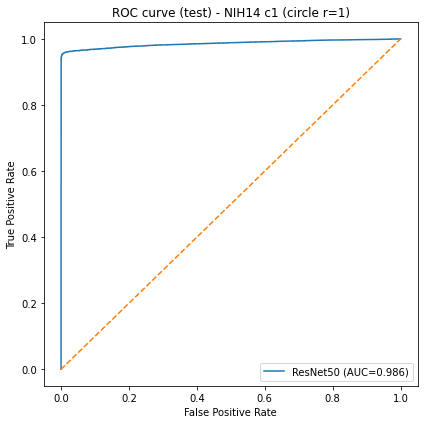

Saved ROC plot to: /home/jupyter-yin10/Image_Analysis/ResNet50/c1/runs/resnet50_imagenet_v2/roc_test.png
Saved metrics to: /home/jupyter-yin10/Image_Analysis/ResNet50/c1/runs/resnet50_imagenet_v2/test_metrics.json


In [1]:
# ResNet50 training for NIH14 circle r=1 (c1) with tqdm progress bars + ETA
# Dataset: /home/jupyter-yin10/Image_Analysis/ResNet50/c1
# Outputs: best checkpoint, ROC plot, metrics JSON

import os, json, random
from pathlib import Path

# ----------------------------
# GPU selection (set before torch uses CUDA)
# ----------------------------
# If you want to force GPU0 (RTX3090), keep this:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import models
from torchvision.models import ResNet50_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ----------------------------
# Config
# ----------------------------
SEED = 42
IMG_SIZE = 448
BATCH_SIZE = 32
EPOCHS = 10
LR = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 4

DATA_ROOT = Path("/home/jupyter-yin10/Image_Analysis/ResNet50/c1")
TRAIN_CSV = DATA_ROOT / "train_manifest.csv"
TEST_CSV  = DATA_ROOT / "test_manifest.csv"

OUT_DIR = DATA_ROOT / "runs" / "resnet50_imagenet_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = OUT_DIR / "best.pt"
ROC_PATH = OUT_DIR / "roc_test.png"
METRICS_PATH = OUT_DIR / "test_metrics.json"

# ----------------------------
# Reproducibility
# ----------------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ----------------------------
# Load manifests and make val split
# ----------------------------
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

if not {"path", "label"}.issubset(train_df.columns):
    raise ValueError("train_manifest.csv must have columns: path,label")
if not {"path", "label"}.issubset(test_df.columns):
    raise ValueError("test_manifest.csv must have columns: path,label")

train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    random_state=SEED,
    stratify=train_df["label"]
)

print("Rows:", "train", len(train_df), "val", len(val_df), "test", len(test_df))
print("Train label counts:\n", train_df["label"].value_counts())
print("Val   label counts:\n", val_df["label"].value_counts())
print("Test  label counts:\n", test_df["label"].value_counts())

# ----------------------------
# Dataset
# ----------------------------
class ManifestDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        path = row["path"]
        label = int(row["label"])

        # NIH images are grayscale; convert to RGB (3ch) for pretrained ResNet50
        img = Image.open(path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img, label

# ----------------------------
# Transforms
# ----------------------------
weights = ResNet50_Weights.IMAGENET1K_V2
imagenet_mean = weights.transforms().mean
imagenet_std  = weights.transforms().std

train_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((IMG_SIZE, IMG_SIZE)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_ds = ManifestDataset(train_df, transform=train_transform)
val_ds   = ManifestDataset(val_df,   transform=eval_transform)
test_ds  = ManifestDataset(test_df,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# ----------------------------
# Model
# ----------------------------
model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ----------------------------
# Helpers
# ----------------------------
def _to_device(x, y):
    x = x.to(device, non_blocking=True)
    y = y.to(device, non_blocking=True)
    return x, y

def train_one_epoch(loader: DataLoader, epoch: int):
    model.train()
    total_loss = 0.0
    n = 0

    pbar = tqdm(loader, desc=f"Train {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = _to_device(x, y)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs
        pbar.set_postfix(loss=(total_loss / max(1, n)))

    return total_loss / max(1, n)

@torch.no_grad()
def eval_loss(loader: DataLoader, epoch: int, name: str = "Val"):
    model.eval()
    total_loss = 0.0
    n = 0

    pbar = tqdm(loader, desc=f"{name} loss {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x, y = _to_device(x, y)
        logits = model(x)
        loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        n += bs
        pbar.set_postfix(loss=(total_loss / max(1, n)))

    return total_loss / max(1, n)

@torch.no_grad()
def predict_probs(loader: DataLoader, name: str = "Eval"):
    model.eval()
    all_probs = []
    all_labels = []

    pbar = tqdm(loader, desc=f"{name} probs", leave=False)
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]  # prob of class 1 (dot)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y.numpy())

    return np.concatenate(all_probs), np.concatenate(all_labels)

# ----------------------------
# Train with best checkpoint by val ROC AUC
# ----------------------------
best_val_auc = -1.0
history = []

epoch_pbar = tqdm(range(1, EPOCHS + 1), desc="Epochs")
for epoch in epoch_pbar:
    tr_loss = train_one_epoch(train_loader, epoch)
    va_loss = eval_loss(val_loader, epoch, name="Val")

    va_probs, va_labels = predict_probs(val_loader, name="Val")
    try:
        va_auc = roc_auc_score(va_labels, va_probs)
    except ValueError:
        va_auc = float("nan")

    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": va_loss, "val_auc": float(va_auc)})

    epoch_pbar.set_postfix(train_loss=tr_loss, val_loss=va_loss, val_auc=va_auc)

    if np.isfinite(va_auc) and va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save({"model_state": model.state_dict(), "epoch": epoch, "val_auc": float(va_auc)}, CKPT_PATH)

print("Best val AUC:", best_val_auc)
print("Saved best checkpoint:", CKPT_PATH)

# ----------------------------
# Test evaluation
# ----------------------------
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()

test_probs, test_labels = predict_probs(test_loader, name="Test")
test_pred = (test_probs >= 0.5).astype(int)

acc = accuracy_score(test_labels, test_pred)
prec, rec, f1, _ = precision_recall_fscore_support(test_labels, test_pred, average="binary", zero_division=0)
cm = confusion_matrix(test_labels, test_pred).tolist()

try:
    test_auc = roc_auc_score(test_labels, test_probs)
except ValueError:
    test_auc = float("nan")

print("\nTest results")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("ROC AUC:", test_auc)
print("\nConfusion matrix:\n", np.array(cm))
print("\nClassification report:\n", classification_report(test_labels, test_pred, digits=4, zero_division=0))

# ----------------------------
# ROC curve plot
# ----------------------------
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ResNet50 (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (test) - NIH14 c1 (circle r=1)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(ROC_PATH, dpi=200)
plt.show()

print("Saved ROC plot to:", ROC_PATH)

# ----------------------------
# Save metrics
# ----------------------------
metrics = {
    "dataset": "NIH14",
    "task": "c1_circle_r1_dot_vs_nodot",
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "best_val_auc": float(best_val_auc),
    "test_accuracy": float(acc),
    "test_precision": float(prec),
    "test_recall": float(rec),
    "test_f1": float(f1),
    "test_roc_auc": float(test_auc),
    "confusion_matrix": cm,
    "best_ckpt_epoch": int(ckpt.get("epoch", -1)),
    "history": history
}

with open(METRICS_PATH, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics to:", METRICS_PATH)
